In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.model_selection import train_test_split

In [ ]:
import os

pwd = os.curdir
save_file = os.path.join(pwd, "Results")
os.makedirs(save_file, exist_ok=True)
seed=822

In [4]:
def opt_price(X, a, b, c):
    p_star = (-1/2) * ((X @ a) / (X @ b))+c/2
    p_star = np.maximum(p_star, c)
    return p_star

## Generate Data

[]
Realized Corr(x,g) = 0.493913330729761 |  mean(D) = 21.749064135013043


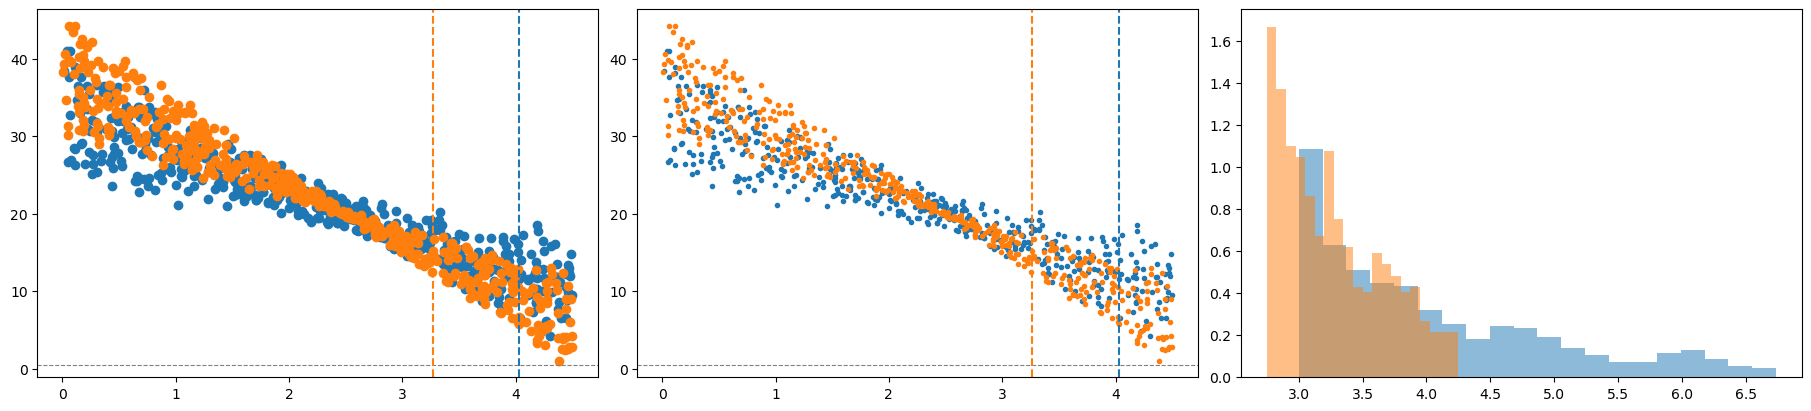

The range of x: -0.498398802465879 1.49501581727873
The range of p_star: 6.734039137645678 2.7519976557610386


In [5]:
def _pack_arrays(df_split):
    """
    Pack a split DataFrame into the dict:
      {'X': X, 'p': p, 'g': g_bool, 'Y': Y}
    where X has an intercept in the first column and the second column is 'x'.
    """
    X_df = df_split[['x']].copy()
    X = np.concatenate([np.ones((len(X_df), 1)), X_df.values], axis=1)  # [1, x]
    p = df_split['p'].to_numpy()
    g_bool = (df_split['g'].to_numpy() == 1)
    Y = df_split['D'].to_numpy()
    return {'X': X, 'p': p, 'g': g_bool, 'Y': Y}

def generate_data_vp(a0, a1, b0, b1, theta_g=0.5, eta = 0, n=5000, rho=0.5, sigma_X=1.0, kappa=0, seed=42, test_size=0.2, stratify_col="g"):
    
    rng = np.random.default_rng(seed)
    
    # 1) group labels
    g = rng.binomial(1, theta_g, size=n)

    # 2) standardized group variable
    z = (g - theta_g) / np.sqrt(theta_g * (1 - theta_g))

    # 3) construct x with target correlation rho
    eps = (rng.uniform(0, 1, size=n) - 1/2)*np.sqrt(12)
    
    # rho = 1
    x = (sigma_X * (rho * z + np.sqrt(1 - rho**2) * eps)) + kappa
    
    # 4) valuation parameters
    a = a0 + a1 * x
    b = b0 + b1 * x

    # 5) support interval [L,U]
    Lc = 0#(1-a)/b+0.3
    Uc = 4.5*np.ones(len(x))#-a/b-0.3


    # 6) valuation and price draws
    p = rng.uniform(Lc, Uc)
    
    # 7) purchase decision
    D = a + b*p  + rng.uniform(-0.5, 0.5, size=n)
    D[np.asarray(g == 0, dtype=bool)] = D[np.asarray(g == 0, dtype=bool)] + 2*rng.uniform(-1, 1, size=len(D[np.asarray(g == 0, dtype=bool)]))
    print(D[D<0])
    
    df = pd.DataFrame({
        "g": g,
        "x": x,
        "p": p,
        "D": D
    })
    corr = np.corrcoef(df["x"], df["g"])[0, 1]

    print("Realized Corr(x,g) =", corr, "|  mean(D) =", df["D"].mean())
    
    X = df[['g', 'x', 'p', 'D']].copy()
    p = X.pop('p')
    g = X.pop('g')
    g = np.asarray(g == 1, dtype=bool)
    Y = X.pop('D')
    X = np.concatenate((np.ones((X.shape[0], 1)), np.array(X)), axis=1)

    a_star = np.asarray([a0, a1])
    b_star = np.asarray([b0, b1])
    p_star = opt_price(X, a_star, b_star, c)
    
    p0_star = p_star[~g]
    p1_star = p_star[g]

    fig, axes = plt.subplots(1, 3, figsize=(18,4), constrained_layout=True)

    j = 0
    axes[j].scatter(p[~g], D[~g], color='tab:blue')
    axes[j].scatter(p[g], D[g], color='tab:orange')
    axes[j].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    axes[j].axvline(np.mean(p0_star), color='tab:blue', label=r'$p_0$', linestyle='--')
    axes[j].axvline(np.mean(p1_star), color='tab:orange', label=r'p1', linestyle='--')

    j = 1
    axes[j].scatter(p[~g], Y[~g], color='tab:blue', marker = '.')
    axes[j].scatter(p[g], Y[g], color='tab:orange', marker = '.')
    axes[j].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    axes[j].axvline(np.mean(p0_star), color='tab:blue', label='p0', linestyle='--')
    axes[j].axvline(np.mean(p1_star), color='tab:orange', label='p1', linestyle='--')

    j = 2
    axes[j].hist(p0_star, bins=20, density=True, alpha=0.5, color='tab:blue', label=r'$p_0^*$')
    axes[j].hist(p1_star, bins=20, density=True, alpha=0.5, color='tab:orange', label=r'$p_1^*$')
    plt.show()

    print("The range of x:", min(x), max(x))
    print("The range of p_star:", max(p_star), min(p_star))
    
     # ---------- Split train/val/test ----------
    stratify_vals = df[stratify_col] if stratify_col else None

    # train + temp
    df_train, df_test = train_test_split(
        df, test_size=test_size,
        stratify=stratify_vals, random_state=seed
    )

    data = {
        'train': _pack_arrays(df_train.reset_index(drop=True)),
        'test' : _pack_arrays(df_test.reset_index(drop=True)),
    }
    
    
    return df, corr, data

# Example
a0, a1, b0, b1 = 30.0, 10.0, -4, -4
c = 1
price_cap = 10

theta_g = 0.5
n = 1000
sigma_X = np.sqrt(theta_g * (1-theta_g))
kappa = 0.5

rho = 0.5
df, corr, data = generate_data_vp(a0, a1, b0, b1, theta_g=theta_g, eta = 0, n=n, rho=rho, sigma_X=sigma_X, kappa=kappa)
a_star = np.asarray([a0,a1])
b_star = np.asarray([b0,b1])

X, p, g, Y = data['train']['X'], data['train']['p'], data['train']['g'], data['train']['Y']
X_test, p_test, g_test, Y_test = data['test']['X'], data['test']['p'], data['test']['g'], data['test']['Y']
n_features = X.shape[1]

# Baseline (No Fairness)

In [6]:
from scipy.optimize import minimize

In [7]:
def mean_square_error(params):
    a = params[:n_features]
    b = params[n_features:]
    linear = X @ a + (X @ b) * p
    return np.mean((linear[g] - Y[g]) ** 2)+ np.mean((linear[~g] - Y[~g]) ** 2)

def constraint_negative_price_elasticity(params):
    b = params[n_features:]
    return -(X @ b)  # X @ b ≤ 0

def constraint_price_lowerbound(params):
    a = params[:n_features]
    b = params[n_features:]
    return X @ a + (X @ b) * c  # (p^* >= c)

def constraint_price_cap(params):
    a = params[:n_features]
    b = params[n_features:]
    return -(X @ a) - (X @ b) * (2*price_cap - c)  # p^* ≤ price_cap

In [8]:
eps = 1e-12
def baseline(data):
    X, p, g, Y = data['train']['X'], data['train']['p'], data['train']['g'], data['train']['Y']
    n_features = X.shape[1]
    
    x0 = np.ones(n_features*2)

    constraints = [
        {'type': 'ineq', 'fun': constraint_negative_price_elasticity},
        {'type': 'ineq', 'fun': constraint_price_lowerbound},
        {'type': 'ineq', 'fun': constraint_price_cap},
    ]

    result = minimize(mean_square_error, x0, method='SLSQP',
                      constraints=constraints,
                      options={'disp': False, 'maxiter': 5000},)
    
    a_hat = result.x[:n_features]
    b_hat = result.x[n_features:]
    print(a_hat, b_hat, max(opt_price(X, a_hat, b_hat, c)))
    
    l2_diff = np.linalg.norm(a_star - a_hat)     # Euclidean distance
    print("L2 norm difference (a):", l2_diff)
    l2_diff = np.linalg.norm(b_star - b_hat)     # Euclidean distance
    print("L2 norm difference (b):", l2_diff)

    p_star = (-1/2) * ((X @ a_hat) / (X @ b_hat))+c/2
    d_star = (X @ a_hat + (X @ b_hat) * p_star) /(X @ a_hat)

    p1_avg = np.mean(p_star[g])
    p0_avg = np.mean(p_star[~g])
    price_gap = np.abs(p1_avg - p0_avg)

    d1_avg = np.mean(d_star[g])
    d0_avg = np.mean(d_star[~g])
    demand_gap = np.abs(d1_avg - d0_avg)

    print('Average Price:', p1_avg, p0_avg)
    print("Price Difference:", price_gap)
    print('Average Demand:', d1_avg, d0_avg)
    print("Demand Difference:", demand_gap)
    
    #################################
    X_test, g_test = data['test']['X'], data['test']['g']
    p_star = opt_price(X_test, a_hat, b_hat, c)
    d_star = (X_test @ a_hat + (X_test @ b_hat) * p_star) /(X_test @ a_hat)

    p1_avg = np.mean(p_star[g_test])
    p0_avg = np.mean(p_star[~g_test])
    price_gap_test = np.abs(p1_avg - p0_avg)

    d1_avg = np.mean(d_star[g_test])
    d0_avg = np.mean(d_star[~g_test])
    demand_gap_test = np.abs(d1_avg - d0_avg)

    return a_hat, b_hat, price_gap, demand_gap, price_gap_test, demand_gap_test

In [9]:
a_hat, b_hat, price_gap, demand_gap, price_gap_test, demand_gap_test = baseline(data)

[29.88543207 10.15389334] [-3.96496535 -4.05927676] 6.89211112326042
L2 norm difference (a): 0.1918566422872907
L2 norm difference (b): 0.06885608856243013
Average Price: 3.2793773244747784 4.035959466518308
Price Difference: 0.7565821420435292
Average Demand: 0.4081403854644427 0.42480432762870945
Demand Difference: 0.016663942164266754


# Tools

In [10]:
def metrics(X, a_star, b_star, p_star, c):
    d = np.maximum(X @ a_star + (X @ b_star) * p_star, 0)
    d_norm=d/(X @ a_star)
    r = sum((p_star-c) * d)
    s = sum(1/2 * d * np.maximum((-X @ a_star)/(X @ b_star)-p_star, 0))
    return d, r, s, d_norm

In [11]:
d_hat, r_hat, s_hat, d_norm_hat = metrics(X, a_hat, b_hat, opt_price(X, a_hat, b_hat, c), c)

## Rawlsian Price Fairness

In [12]:
beta_list = []

p_feo_test = []
rev_feo_test, sur_feo_test = [], []

beta_bar = max(opt_price(X, a_hat, b_hat, c))
beta_under_bar = min(opt_price(X, a_hat, b_hat, c))

for beta in np.linspace(0,1,6):
    true_beta = (1-beta) * (beta_bar) + beta * beta_under_bar
    
    def constraint_rawlsian_price(params):
        a = params[:n_features]
        b = params[n_features:]
        return -2 * (X @ b) * true_beta -(X @ a) + c * (X @ b) # p^* ≤ true_beta
    
    x0 = np.ones(2*n_features)
    
    constraints = [
            {'type': 'ineq', 'fun': constraint_negative_price_elasticity},
            {'type': 'ineq', 'fun': constraint_price_lowerbound},
            {'type': 'ineq', 'fun': constraint_price_cap},
            {'type': 'ineq', 'fun': constraint_rawlsian_price},
        ]
    
    result = minimize(
        fun=mean_square_error,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': False}
    )
    
    a_val = result.x[:n_features]
    b_val = result.x[n_features:]

    beta_list.append(beta)
    
    #############################Test#####################################
    if np.abs(X @ b_val).min() > 1e-6:
        p_star_test = opt_price(X_test, a_val, b_val, c)
    else:
        p_star_test = np.full(X_test.shape[0], true_beta)
    d_test, r_test, s_test, d_norm_test = metrics(X_test, a_star, b_star, p_star_test, c)
    
    p_feo_test.append(p_star_test)
    
    rev_feo_test.append(r_test)
    sur_feo_test.append(s_test)
    

In [13]:
p_list_test = []
rev_list_test, sur_list_test = [], []

for beta in beta_list:
    true_beta = (1-beta) * (beta_bar) + beta * beta_under_bar
    p_star_test = np.maximum(np.minimum(-1/2 * (X_test @ a_hat)/(X_test @ b_hat) + c/2, true_beta), c)
    p_list_test.append(p_star_test)
    
    d_test, r_test, s_test, d_norm_test = metrics(X_test, a_star, b_star, p_star_test, c)
    
    rev_list_test.append(r_test)
    sur_list_test.append(s_test)

In [14]:
import os
fontsize = 24
my_labels = [f'{a:.1f}' for a in beta_list]

def plot_default_boxplot(data_set, filename=None, y_limits=None):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.boxplot(data_set, labels=my_labels, patch_artist=True,
               boxprops=dict(facecolor='#addd8e', color='black', alpha=0.7),
               medianprops=dict(color='black', linewidth=3))

    if y_limits:
        ax.set_ylim(y_limits)

    ax.tick_params(axis='both', which='major', labelsize=24)
    ax.set_xlabel(r'$\alpha$', fontsize=36)

    plt.tight_layout()

    if filename:
        plt.savefig(filename, bbox_inches="tight")
        print(f"Plot saved as: {filename}")

    plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_grouped_boxplot(set0, set1, filename=None, y_limits=None, mean_plot=False, price=True):
    """
    Plots grouped boxplots. Since markers cannot have hatches in Matplotlib,
    outliers are filled with colors matching the boxes to ensure visual consistency.
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    positions = np.arange(len(my_labels)) * 2.0
    width = 0.6

    flier0 = dict(marker='o', markerfacecolor='#1f78b4', markeredgecolor='black',
                  markersize=6, alpha=1)
    flier1 = dict(marker='o', markerfacecolor='#fdbf6f', markeredgecolor='black',
                  markersize=6, alpha=0.7)

    # --- 2. Generate Boxplots ---
    box0 = ax.boxplot(set0, positions=positions - width/2, widths=width,
                      patch_artist=True, manage_ticks=False,
                      showmeans=mean_plot, meanline=True, flierprops=flier0)

    box1 = ax.boxplot(set1, positions=positions + width/2, widths=width,
                      patch_artist=True, manage_ticks=False,
                      showmeans=mean_plot, meanline=True, flierprops=flier1)

    # --- 3. Style Box Bodies (Applying Patterns) ---
    for b0 in box0['boxes']:
        b0.set(facecolor='#1f78b4', alpha=0.7, edgecolor='black')
    for b1 in box1['boxes']:
        b1.set(facecolor='#fdbf6f', alpha=0.7, edgecolor='black')

    # --- 4. Style Mean Lines ---
    for median in box0['medians'] + box1['medians']:
        median.set(color='black', linewidth=5, linestyle='-')

    # --- 5. Style Median Lines ---
    if mean_plot:
        for mean in box0['means'] + box1['means']:
            mean.set(color='red', linewidth=5, linestyle=(0, (2, 1)))

    # --- 6. Formatting Axes ---
    ax.set_xticks(positions)
    ax.set_xticklabels(my_labels)
    ax.tick_params(axis='both', labelsize=24)
    ax.set_xlabel(r'$\alpha$', fontsize=36)

    if y_limits:
        ax.set_ylim(y_limits)

    # --- 7. Legend Configuration ---
    if price == True:
        label0, label1 = '$p_0$', '$p_1$'
    else:
        label0, label1 = '$d_0$', '$d_1$'

    legend_elements = [
        Patch(facecolor='#1f78b4', edgecolor='black', label=label0, alpha=0.7), #hatch='//'
        Patch(facecolor='#fdbf6f', edgecolor='black', label=label1, alpha=0.7), #hatch='\\\\'
    ]

    if mean_plot:
        legend_elements.insert(2, Line2D([0], [0], color='red', lw=5, ls=(0, (2, 1)), label='Mean'))

    ax.legend(handles=legend_elements, fontsize=28, loc='lower center',
              bbox_to_anchor=(0.5, 1.01), ncol=3, frameon=True)

    # Padding for the legend outside the axis
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if filename:
        plt.savefig(filename, bbox_inches="tight")
    plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6756\2668010218.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_set, labels=my_labels, patch_artist=True,


Plot saved as: .\Results\seed_822\Rawlsian_Price_FEO.pdf


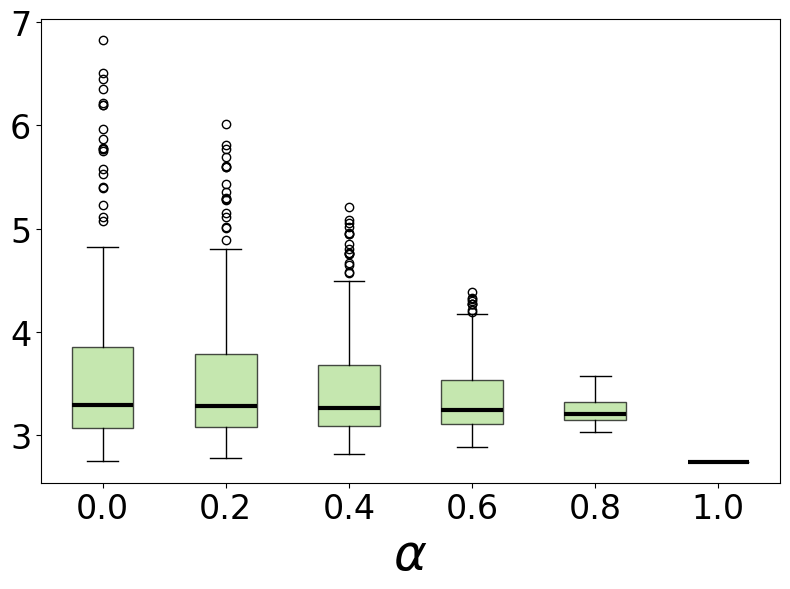

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6756\2668010218.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_set, labels=my_labels, patch_artist=True,


Plot saved as: .\Results\seed_822\Rawlsian_Price_EFO.pdf


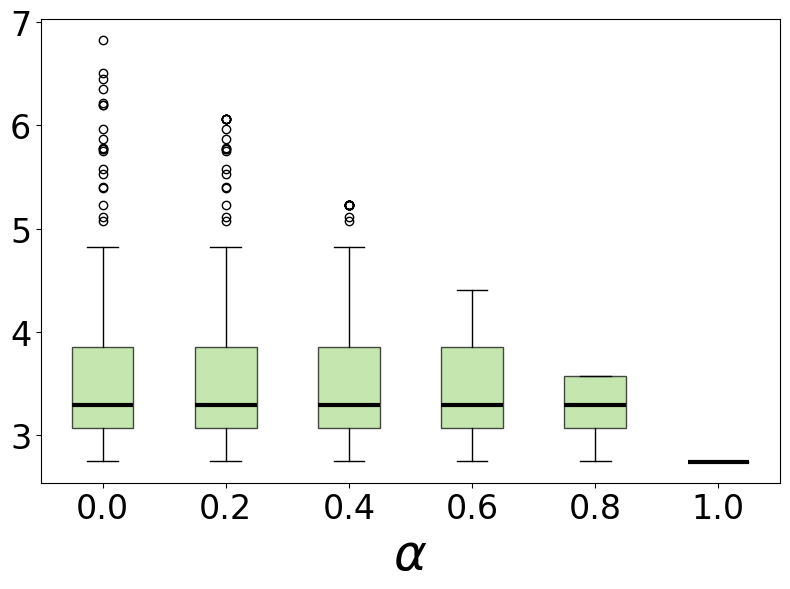

In [16]:
dir = os.path.join(save_file, f'seed_{seed}')
os.makedirs(dir, exist_ok=True)
plot_default_boxplot(p_feo_test, filename=os.path.join(dir, f"Rawlsian_Price_FEO.pdf"))
plot_default_boxplot(p_list_test, filename=os.path.join(dir, f"Rawlsian_Price_EFO.pdf"))

In [17]:
def normalize_to_percentage(data_list):
    # Calculate percentage relative to the first element (alpha=0)
    base_value = data_list[0]
    return [(val / base_value) * 100 for val in data_list]

# --- Create Table ---
target_alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0] #[0.2, 0.4, 0.6, 0.8, 1.0]
indices = [target_alphas.index(a) for a in target_alphas]

wel_feo_test = [rev_feo_test[i] + sur_feo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_feo_test)
sur_norm = normalize_to_percentage(sur_feo_test)
wel_norm = normalize_to_percentage(wel_feo_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)
target_alphas

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   99.85   99.13   97.58   94.62   86.35
S(α)/S(0)  100.0  105.46  112.29  121.00  132.33  178.65
W(α)/W(0)  100.0  101.71  103.50  105.35  107.14  116.98
--------------------------------------------------


[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

In [18]:
# --- Calculation ---
wel_list_test = [rev_list_test[i] + sur_list_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_list_test)
sur_norm = normalize_to_percentage(sur_list_test)
wel_norm = normalize_to_percentage(wel_list_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   99.99   99.72   98.69   95.78   86.35
S(α)/S(0)  100.0  100.74  104.26  111.61  128.27  178.65
W(α)/W(0)  100.0  100.24  101.23  102.98  106.56  116.98
--------------------------------------------------


## Rawlsian Demand Fairness

In [19]:
beta_list = []

d_feo_ex_ante = []
d_feo_ex_post = []
rev_feo_test, sur_feo_test = [], []

beta_under_bar = min(d_norm_hat)
beta_bar = 0.5#max(d_norm_hat)

for beta in np.linspace(0, 1, 6):
    true_beta = (1-beta) * beta_under_bar + beta * beta_bar
    
    def constraint_rawlsian_demand(params):
        a = params[:n_features]
        b = params[n_features:]
        return -((1-true_beta) * (X @ a_hat) + c/2 * (X @ b_hat)) * (X @ b) + 0.5 * (X @ b_hat) * (X @ a) # d^* ≥ true_beta 
    
    x0 = np.ones(2*n_features)
    
    constraints = [
            {'type': 'ineq', 'fun': constraint_negative_price_elasticity},
            {'type': 'ineq', 'fun': constraint_price_lowerbound},
            {'type': 'ineq', 'fun': constraint_price_cap},
            {'type': 'ineq', 'fun': constraint_rawlsian_demand},
        ]
    
    result = minimize(
        fun=mean_square_error,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': False}
    )
    
    a_val = result.x[:n_features]
    b_val = result.x[n_features:]

    beta_list.append(beta)
    
    #############################Test#####################################
    
    p_star_test = opt_price(X_test, a_val, b_val, c)
    d_test, r_test, s_test, d_norm_test = metrics(X_test, a_star, b_star, p_star_test, c)
    _d_test = metrics(X_test, a_hat, b_hat, p_star_test, c)[-1]

    d_feo_ex_ante.append(_d_test)
    d_feo_ex_post.append(d_norm_test)

    rev_feo_test.append(r_test)
    sur_feo_test.append(s_test)

In [20]:
d_efo_ex_ante = []
d_efo_ex_post = []
rev_list_test, sur_list_test = [], []

for beta in beta_list:
    true_beta = (1-beta) * beta_under_bar + beta * beta_bar
    
    d_star_test = np.maximum(1/2 + c * (X_test @ b_hat)/(2*(X_test @ a_hat)), true_beta)
    d_efo_ex_ante.append(d_star_test)
    p_star_test=np.maximum((d_star_test - 1)*(X_test @ a_hat)/(X_test @ b_hat),c)
    
    d_test, r_test, s_test, d_norm = metrics(X_test, a_star, b_star, p_star_test, c)
    
    d_efo_ex_post.append(d_norm)
    rev_list_test.append(r_test)
    sur_list_test.append(s_test)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6756\2668010218.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_set, labels=my_labels, patch_artist=True,


Plot saved as: .\Results\seed_822\Rawlsian_ExAnte_Demand_FEO.pdf


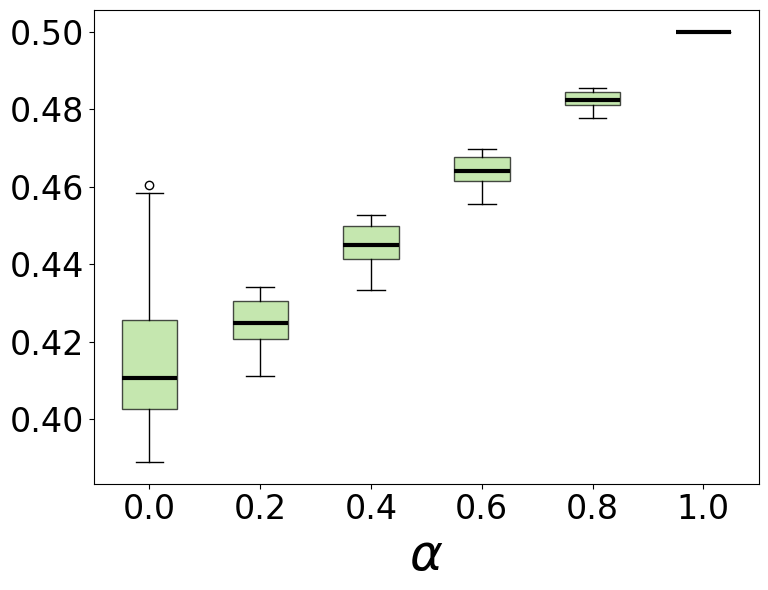

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6756\2668010218.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_set, labels=my_labels, patch_artist=True,


Plot saved as: .\Results\seed_822\Rawlsian_ExAnte_Demand_EFO.pdf


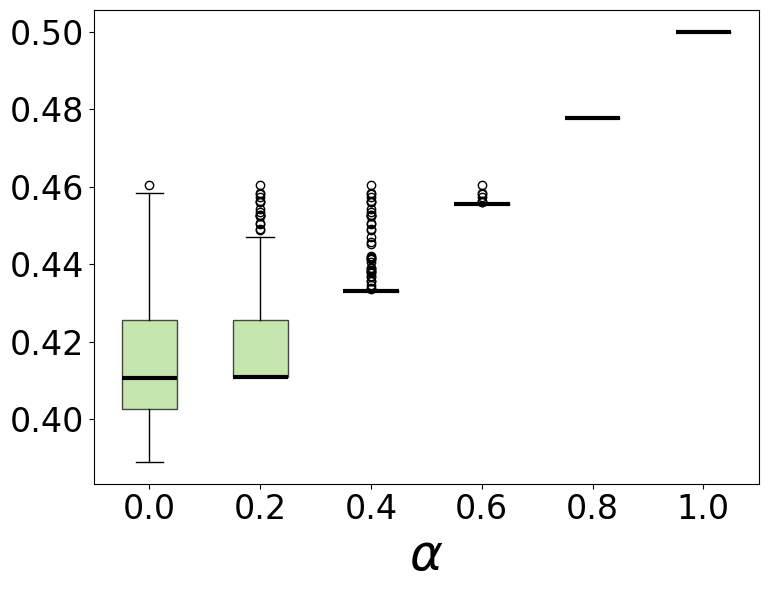

In [21]:
plot_default_boxplot(d_feo_ex_ante, filename=os.path.join(dir, f"Rawlsian_ExAnte_Demand_FEO.pdf"))
plot_default_boxplot(d_efo_ex_ante, filename=os.path.join(dir, f"Rawlsian_ExAnte_Demand_EFO.pdf"))

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6756\2668010218.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_set, labels=my_labels, patch_artist=True,


Plot saved as: .\Results\seed_822\Rawlsian_ExPost_Demand_FEO.pdf


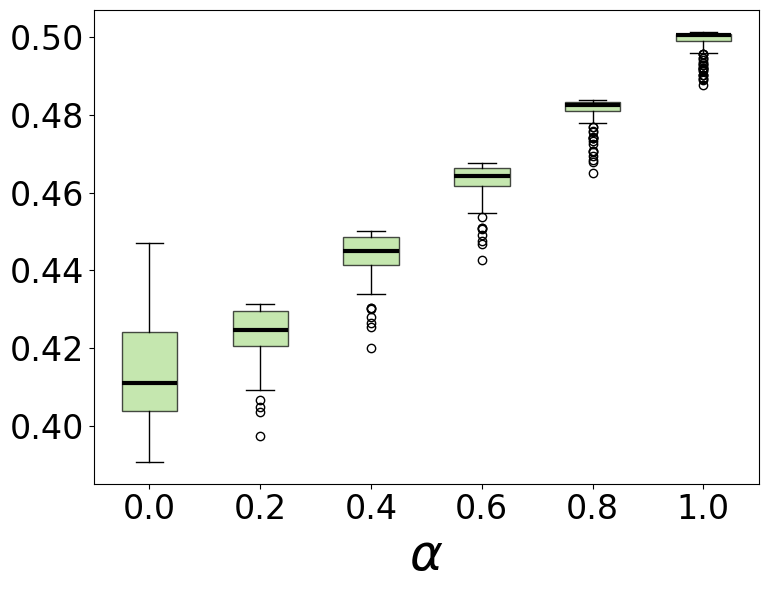

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6756\2668010218.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_set, labels=my_labels, patch_artist=True,


Plot saved as: .\Results\seed_822\Rawlsian_ExPost_Demand_EFO.pdf


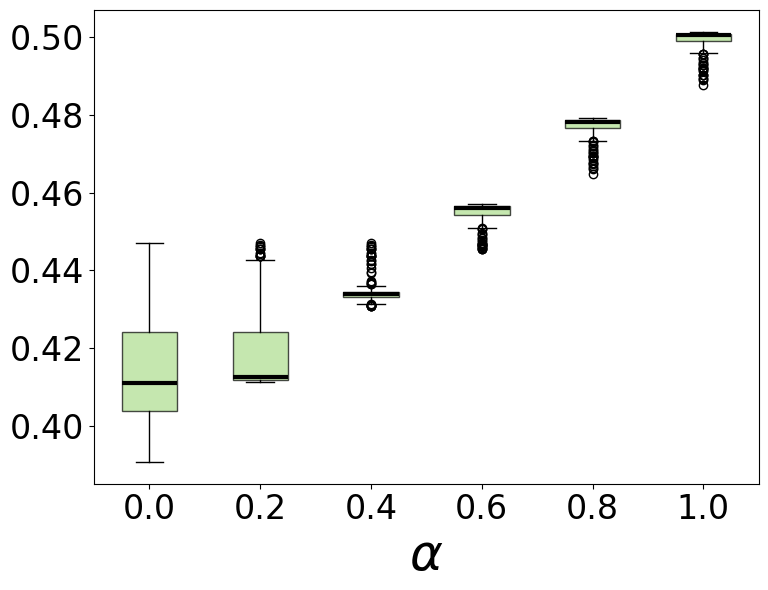

In [22]:
plot_default_boxplot(d_feo_ex_post, filename=os.path.join(dir, f"Rawlsian_ExPost_Demand_FEO.pdf"))
plot_default_boxplot(d_efo_ex_post, filename=os.path.join(dir, f"Rawlsian_ExPost_Demand_EFO.pdf"))

In [23]:
# --- Calculation ---
wel_feo_test = [rev_feo_test[i] + sur_feo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_feo_test)
sur_norm = normalize_to_percentage(sur_feo_test)
wel_norm = normalize_to_percentage(wel_feo_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)


Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   99.77   99.39   98.60   97.44   95.96
S(α)/S(0)  100.0  103.42  113.44  123.48  133.39  143.33
W(α)/W(0)  100.0  100.98  104.05  106.86  109.38  111.68
--------------------------------------------------


In [24]:
# --- Calculation ---
wel_list_test = [rev_list_test[i] + sur_list_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_list_test)
sur_norm = normalize_to_percentage(sur_list_test)
wel_norm = normalize_to_percentage(wel_list_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   99.96   99.67   98.97   97.75   95.96
S(α)/S(0)  100.0  102.04  108.99  118.86  130.77  143.31
W(α)/W(0)  100.0  100.65  102.77  105.57  108.71  111.68
--------------------------------------------------


# Parity-wise Price Fairness

In [25]:
alpha_list = []

p0_feo_set, p1_feo_set = [], []
rev_feo_test, sur_feo_test = [], []

for alpha in np.linspace(0,1,6):
    def constraint_parity1_price(params):
        a = params[:n_features]
        b = params[n_features:]
        p1=np.mean((-1/2) * ((X[g] @ a) / (X[g] @ b))+c/2)
        p0=np.mean((-1/2) * ((X[~g] @ a) / (X[~g] @ b))+c/2)
        return (1-alpha) * price_gap - p1 + p0
    
    def constraint_parity2_price(params):
        a = params[:n_features]
        b = params[n_features:]
        p1=np.mean((-1/2) * ((X[g] @ a) / (X[g] @ b))+c/2)
        p0=np.mean((-1/2) * ((X[~g] @ a) / (X[~g] @ b))+c/2)
        return (1-alpha) * price_gap + p1 - p0
    
    x0 = np.concatenate((a_hat, b_hat))
    
    constraints = [
            {'type': 'ineq', 'fun': constraint_negative_price_elasticity},
            {'type': 'ineq', 'fun': constraint_price_lowerbound},
            {'type': 'ineq', 'fun': constraint_price_cap},
            {'type': 'ineq', 'fun': constraint_parity1_price},
            {'type': 'ineq', 'fun': constraint_parity2_price},
        ]
    
    result = minimize(
        fun=mean_square_error,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': False}
    )
    
    a_val = result.x[:n_features]
    b_val = result.x[n_features:]
    
    
    #############################Test#####################################
    p_star_test = opt_price(X_test, a_val, b_val, c)
    d_test, r_test, s_test, d_norm_test = metrics(X_test, a_star, b_star, p_star_test, c)

    p0_feo_set.append(p_star_test[~g_test])
    p1_feo_set.append(p_star_test[g_test])
    
    rev_feo_test.append(r_test)
    sur_feo_test.append(s_test)
    
    alpha_list.append(alpha)

In [26]:
p0_efo_set, p1_efo_set = [], []
rev_list_test, sur_list_test = [], []

for alpha in np.linspace(0,1,6):
    def constraint3(p):
         return p - c

    def constraint4(p):
         return price_cap - p
    
    #############################Test#####################################
    
    def negative_revenue_test(p):
        p = np.asarray(p)
        term1 = X_test @ a_hat
        term2 = (X_test @ b_hat) * p
        total = np.dot(p-c, term1+term2)
        return -np.sum(total)
    
    def constraint1_test(p):
        p0, p1 = np.mean(p[~g_test]), np.mean(p[g_test])
        return (1 - alpha) * price_gap_test - (p1 - p0)

    def constraint2_test(p):
        p0, p1 = np.mean(p[~g_test]), np.mean(p[g_test])
        return (1 - alpha) * price_gap_test - (p0 - p1)
    
    x0 = np.ones(X_test.shape[0]) * c
    
    constraints = [
        {'type': 'ineq', 'fun': constraint1_test},
        {'type': 'ineq', 'fun': constraint2_test},
        {'type': 'ineq', 'fun': constraint3},
        {'type': 'ineq', 'fun': constraint4}
    ]
    
    result = minimize(
        fun=negative_revenue_test,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': False}
    )
    
    p_star_test = result.x
    p0_efo_set.append(p_star_test[~g_test])
    p1_efo_set.append(p_star_test[g_test])
    
    d_test, r_test, s_test, d_norm_test = metrics(X_test, a_star, b_star, p_star_test, c)
    rev_list_test.append(r_test)
    sur_list_test.append(s_test)
    p_list_test.append(p_star_test)

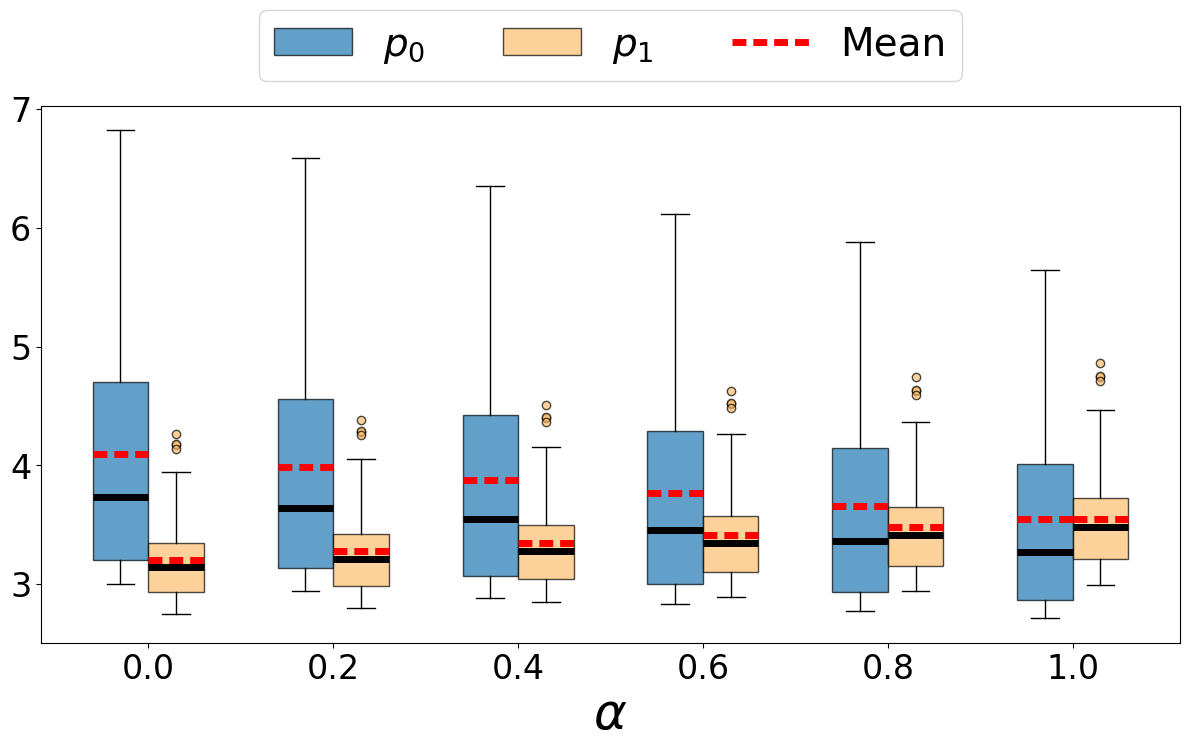

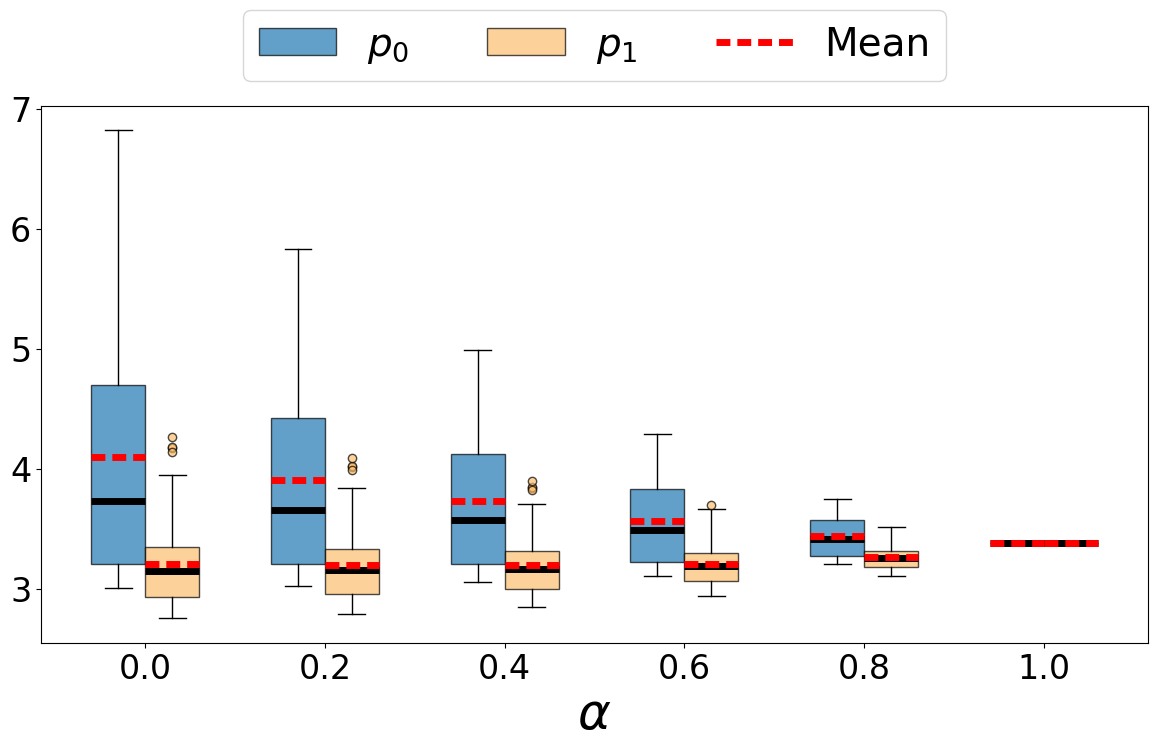

In [27]:
plot_grouped_boxplot(p0_efo_set, p1_efo_set, mean_plot=True, filename=os.path.join(dir, f"Parity_Price_Test_EFO.pdf"))
plot_grouped_boxplot(p0_feo_set, p1_feo_set, mean_plot=True, filename=os.path.join(dir, f"Parity_Price_Test_FEO.pdf"))

In [28]:
# --- Calculation ---
wel_feo_test = [rev_feo_test[i] + sur_feo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_feo_test)
sur_norm = normalize_to_percentage(sur_feo_test)
wel_norm = normalize_to_percentage(wel_feo_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   99.74   98.82   97.34   95.43   93.04
S(α)/S(0)  100.0  106.80  113.76  119.95  123.57  122.37
W(α)/W(0)  100.0  102.08  103.78  104.84  104.77  102.78
--------------------------------------------------


In [29]:
# --- Calculation ---
wel_list_test = [rev_list_test[i] + sur_list_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_list_test)
sur_norm = normalize_to_percentage(sur_list_test)
wel_norm = normalize_to_percentage(wel_list_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   99.92   99.61   99.08   98.32   97.34
S(α)/S(0)  100.0  101.22  102.66  104.34  106.23  108.36
W(α)/W(0)  100.0  100.35  100.63  100.83  100.95  101.00
--------------------------------------------------


# Parity-wise Demand Fairness

In [30]:
alpha_list = []
d0_feo_ex_ante, d1_feo_ex_ante = [], []
d0_feo_ex_post, d1_feo_ex_post = [], []
rev_feo_test, sur_feo_test = [], []

for alpha in np.linspace(0,1,6):
    def constraint_parity1_demand(params):
        a = params[:n_features]
        b = params[n_features:]
        g1 = np.mean(1+((X[g] @ b_hat)*(-0.5*(X[g] @ a) / (X[g] @ b + eps)+c/2))/ (X[g] @ a_hat))
        g0 = np.mean(1+((X[~g] @ b_hat)*(-0.5*(X[~g] @ a) / (X[~g] @ b + eps)+c/2))/ (X[~g] @ a_hat))
        return (1-alpha) * demand_gap - g1 + g0
    
    def constraint_parity2_demand(params):
        a = params[:n_features]
        b = params[n_features:]
        g1 = np.mean(1+((X[g] @ b_hat)*(-0.5*(X[g] @ a) / (X[g] @ b + eps)+c/2))/ (X[g] @ a_hat))
        g0 = np.mean(1+((X[~g] @ b_hat)*(-0.5*(X[~g] @ a) / (X[~g] @ b + eps)+c/2))/ (X[~g] @ a_hat))
        return (1-alpha) * demand_gap + g1 - g0
    
    x0 = np.concatenate((a_hat, b_hat))
    
    constraints = [
            {'type': 'ineq', 'fun': constraint_negative_price_elasticity},
            {'type': 'ineq', 'fun': constraint_price_lowerbound},
            {'type': 'ineq', 'fun': constraint_price_cap},
            {'type': 'ineq', 'fun': constraint_parity1_demand},
            {'type': 'ineq', 'fun': constraint_parity2_demand},
        ]
    
    result = minimize(
        fun=mean_square_error,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': False}
    )
    
    a_val = result.x[:n_features]
    b_val = result.x[n_features:]
    
    #############################Test#####################################
    p_star_test = opt_price(X_test, a_val, b_val, c)
    d_test, r_test, s_test, d_norm_test = metrics(X_test, a_star, b_star, p_star_test, c)
    _d_test = metrics(X_test, a_hat, b_hat, p_star_test, c)[-1]

    d0_feo_ex_ante.append(_d_test[~g_test])
    d1_feo_ex_ante.append(_d_test[g_test])
    d0_feo_ex_post.append(d_norm_test[~g_test])
    d1_feo_ex_post.append(d_norm_test[g_test])
    
    rev_feo_test.append(r_test)
    sur_feo_test.append(s_test)
    
    alpha_list.append(alpha)

In [31]:
d0_efo_ex_ante, d1_efo_ex_ante = [], []
d0_efo_ex_post, d1_efo_ex_post = [], []
rev_list_test, sur_list_test = [], []

for alpha in np.linspace(0,1,6):
    
    def constraint1_test(p):
        d0_test, d1_test = np.mean((X_test[~g_test] @ a_hat + (X_test[~g_test] @ b_hat) * p[~g_test]) /(X_test[~g_test] @ a_hat)), np.mean((X_test[g_test] @ a_hat + (X_test[g_test] @ b_hat) * p[g_test]) /(X_test[g_test] @ a_hat))
        return (1 - alpha) * demand_gap_test - (d1_test - d0_test)

    def constraint2_test(p):
        d0_test, d1_test = np.mean((X_test[~g_test] @ a_hat + (X_test[~g_test] @ b_hat) * p[~g_test]) /(X_test[~g_test] @ a_hat)), np.mean((X_test[g_test] @ a_hat + (X_test[g_test] @ b_hat) * p[g_test]) /(X_test[g_test] @ a_hat))
        return (1 - alpha) * demand_gap_test - (d0_test - d1_test)
    
    x0 = np.ones(X_test.shape[0]) * c
    
    constraints = [
        {'type': 'ineq', 'fun': constraint1_test},
        {'type': 'ineq', 'fun': constraint2_test},
        {'type': 'ineq', 'fun': constraint3},
        {'type': 'ineq', 'fun': constraint4}
    ]
    
    result = minimize(
        fun=negative_revenue_test,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': False}
    )
    
    p_star_test = result.x
    
    d_test, r_test, s_test, d_norm_test = metrics(X_test, a_star, b_star, p_star_test, c)
    _d_test = metrics(X_test, a_hat, b_hat, p_star_test, c)[-1]
    d0_efo_ex_ante.append(_d_test[~g_test])
    d1_efo_ex_ante.append(_d_test[g_test])
    d0_efo_ex_post.append(d_norm_test[~g_test])
    d1_efo_ex_post.append(d_norm_test[g_test])
    
    rev_list_test.append(r_test)
    sur_list_test.append(s_test)

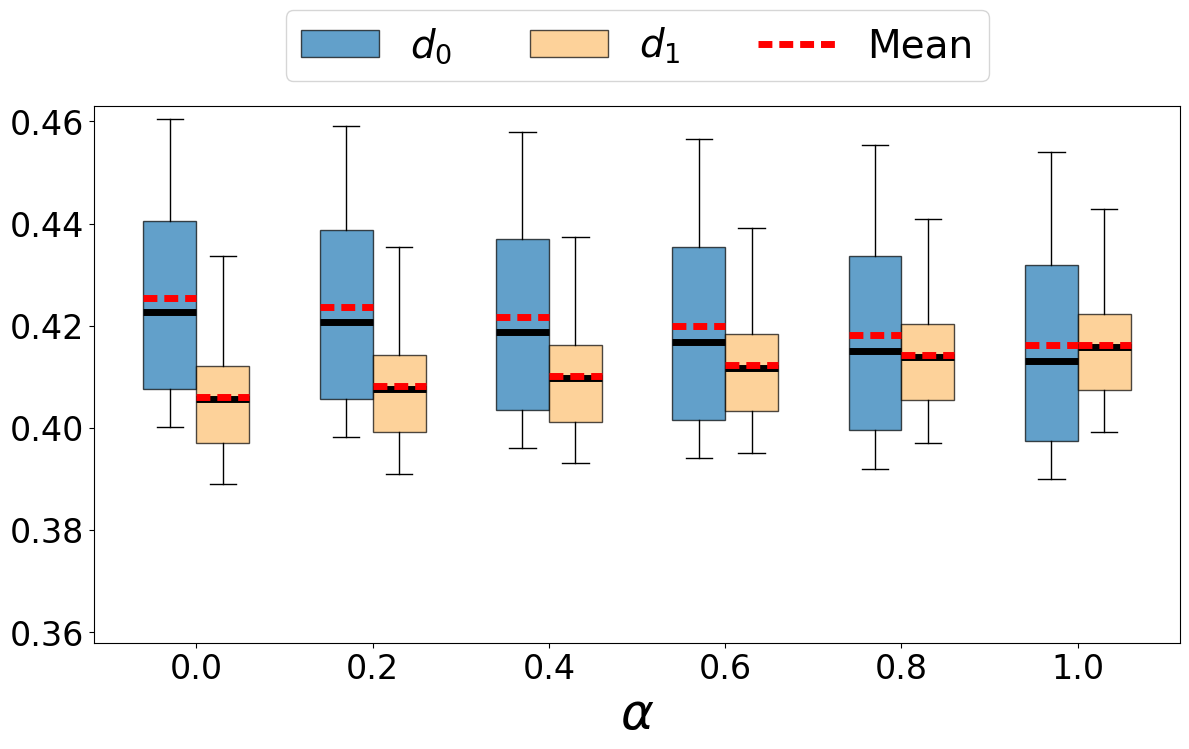

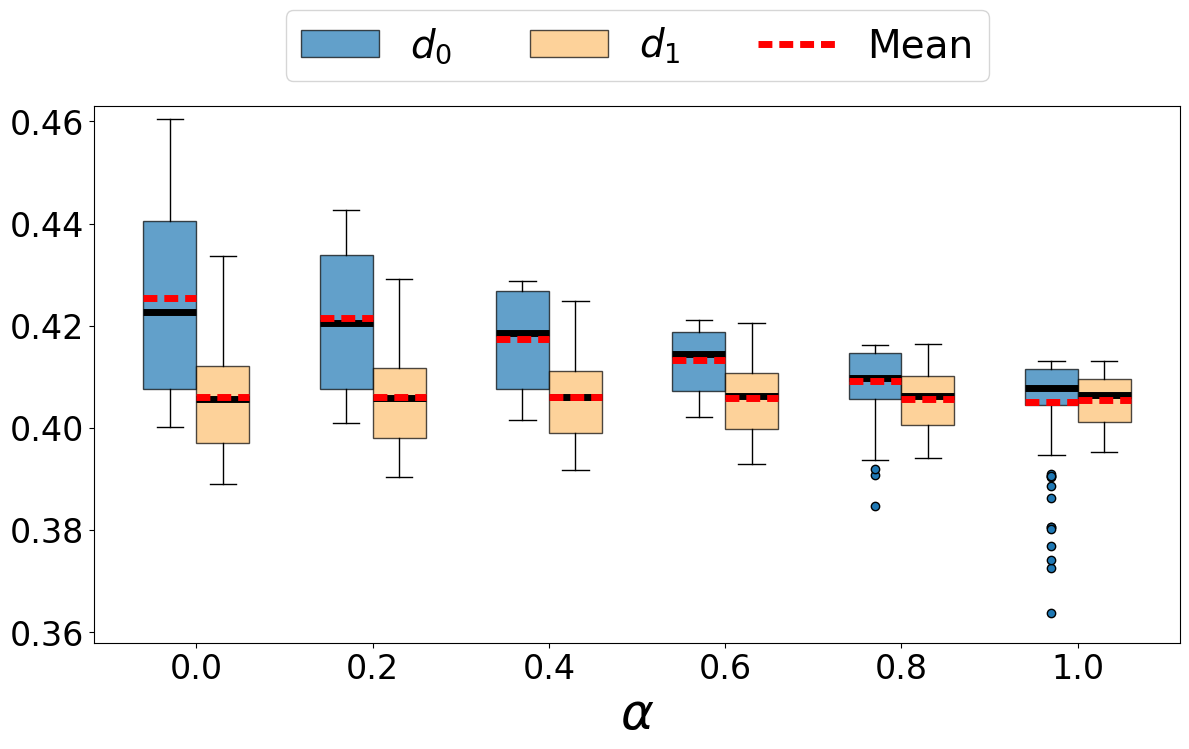

In [32]:
plot_grouped_boxplot(d0_efo_ex_ante, d1_efo_ex_ante, y_limits=[0.358,0.463],mean_plot=True, filename=os.path.join(dir, f"Parity_ExAnte_Demand_EFO.pdf"), price=False)
plot_grouped_boxplot(d0_feo_ex_ante, d1_feo_ex_ante, y_limits=[0.358,0.463],mean_plot=True, filename=os.path.join(dir, f"Parity_ExAnte_Demand_FEO.pdf"), price=False)

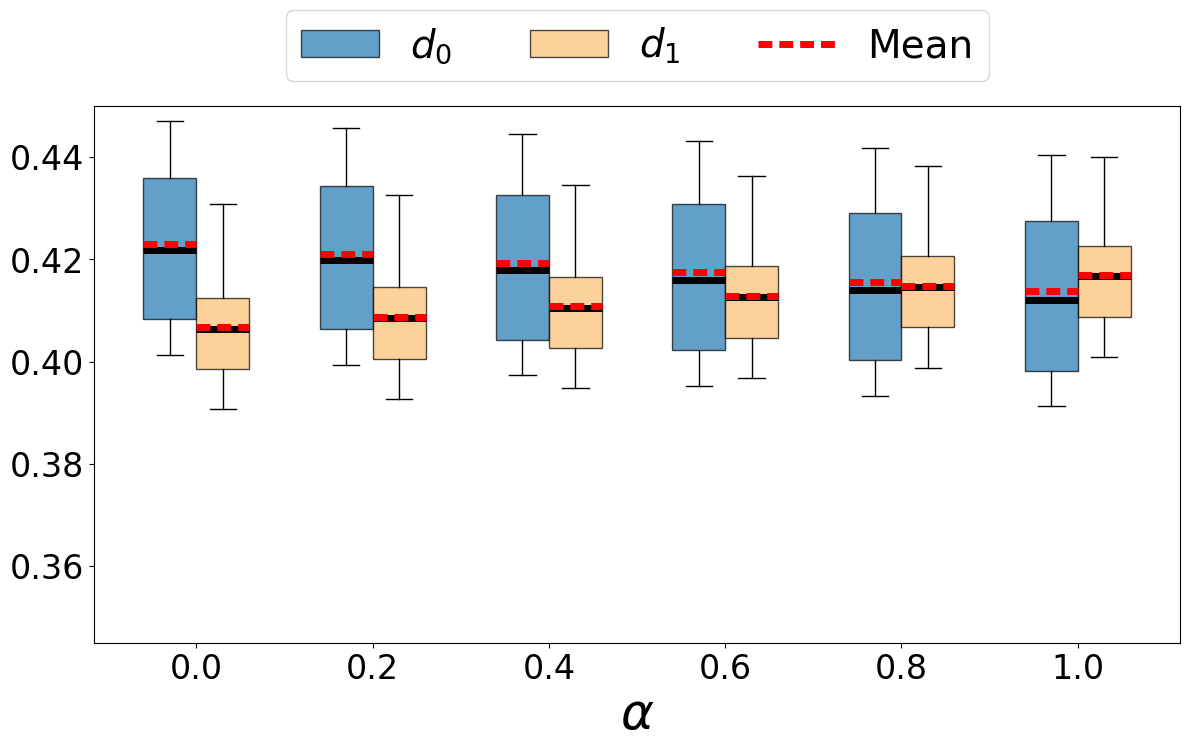

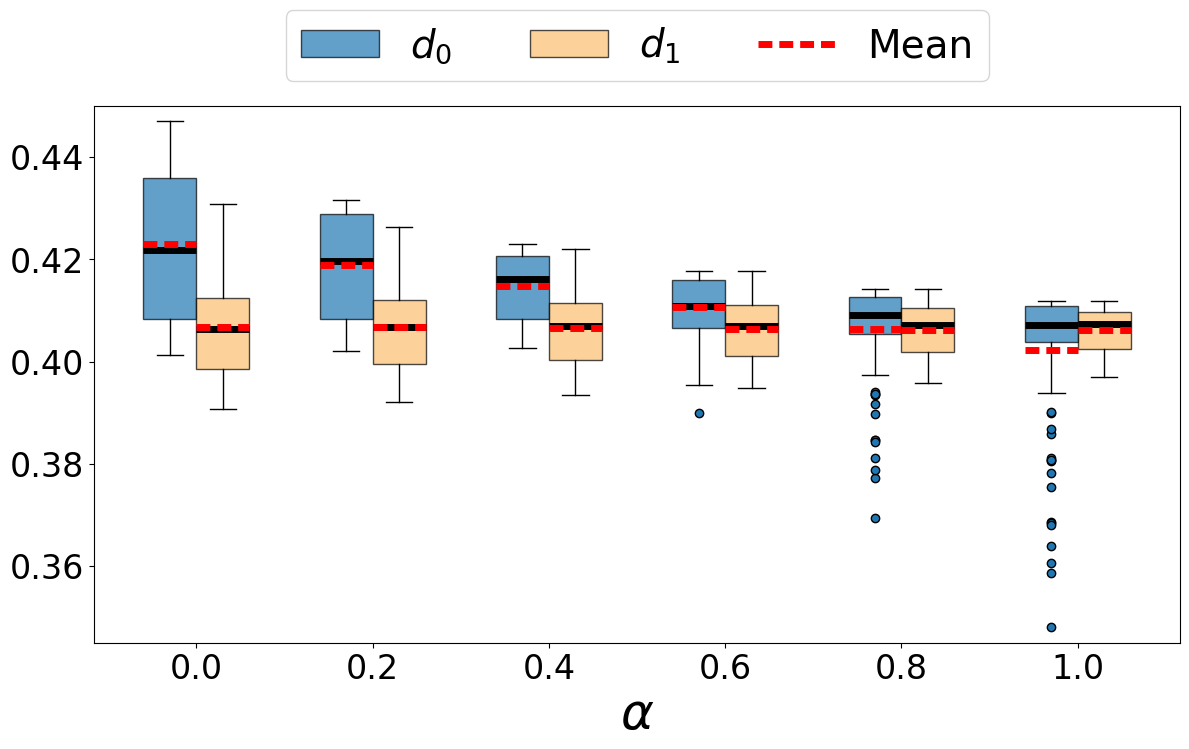

In [33]:
plot_grouped_boxplot(d0_efo_ex_post, d1_efo_ex_post, y_limits=[0.345,0.45], mean_plot=True, filename=os.path.join(dir, f"Parity_ExPost_Demand_EFO.pdf"), price=False)
plot_grouped_boxplot(d0_feo_ex_post, d1_feo_ex_post, y_limits=[0.345,0.45], mean_plot=True, filename=os.path.join(dir, f"Parity_ExPost_Demand_FEO.pdf"), price=False)

In [34]:
# --- Calculation ---
wel_feo_test = [rev_feo_test[i] + sur_feo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_feo_test)
sur_norm = normalize_to_percentage(sur_feo_test)
wel_norm = normalize_to_percentage(wel_feo_test)

# --- Create Table ---
target_alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0] #[i/10 for i in range(1,11)] #
indices = [target_alphas.index(a) for a in target_alphas]

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)


Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0    0.2    0.4    0.6    0.8    1.0
R(α)/R(0)  100.0  99.96  99.89  99.79  99.65  99.48
S(α)/S(0)  100.0  98.72  97.45  96.19  94.96  93.74
W(α)/W(0)  100.0  99.55  99.08  98.60  98.09  97.57
--------------------------------------------------


In [35]:
# --- Calculation ---
wel_list_test = [rev_list_test[i] + sur_list_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_list_test)
sur_norm = normalize_to_percentage(sur_list_test)
wel_norm = normalize_to_percentage(wel_list_test)

# Organize data with English labels
data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

# Create DataFrame and Transpose to match the horizontal format
df = pd.DataFrame(data).set_index('α').T

# --- Display ---
print("Table: Normalized Performance Measures (%)") # English Caption
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0    0.2    0.4    0.6    0.8    1.0
R(α)/R(0)  100.0  99.99  99.99  99.97  99.95  99.93
S(α)/S(0)  100.0  99.98  99.97  99.96  99.96  99.96
W(α)/W(0)  100.0  99.99  99.98  99.97  99.96  99.94
--------------------------------------------------
